In [2]:
#Task 1: Date Feature Engineering
import pandas as pd
df = pd.read_csv("q3_retail_promotions.csv")
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [8]:
#Convert transaction_date to Datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

#Extract Date Features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

#Create is_month_end Feature
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head())

  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0


In [10]:
#Task 2: Temporal Train-Test Split
#sort data by date
df = df.sort_values(by='transaction_date')
print(df)

     transaction_date  store_id store_size location_type  promotion_type  \
0          2022-01-01        28      small    semi-urban       free_gift   
1          2022-01-01         5     medium    semi-urban       free_gift   
2          2022-01-02        13      small    semi-urban  loyalty_points   
3          2022-01-02        17      small         urban       free_gift   
4          2022-01-03        50     medium    semi-urban            bogo   
...               ...       ...        ...           ...             ...   
1195       2024-12-28        39      large         urban            bogo   
1196       2024-12-28        44     medium         urban  category_offer   
1197       2024-12-29        47      large    semi-urban            bogo   
1198       2024-12-31        25      small         urban            bogo   
1199       2024-12-31        37     medium         urban  category_offer   

      is_weekend  is_festival  competition_density  items_sold  year  month  \
0       

In [11]:
#Perform 80-20 Temporal Split
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Training set size:", train_df.shape)
print("Testing set size:", test_df.shape)

Training set size: (960, 13)
Testing set size: (240, 13)


In [12]:
#Verify Split
print("Train date range:", train_df['transaction_date'].min(), "to", train_df['transaction_date'].max())
print("Test date range:", test_df['transaction_date'].min(), "to", test_df['transaction_date'].max())

Train date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


## Task 2: Temporal Train-Test Split

The dataset is sorted based on the transaction_date to maintain the natural time order of events. The first 80% of the data is used as the training set, while the most recent 20% is used as the test set.

A random split is inappropriate for time-ordered data because it can lead to data leakage. In real-world scenarios, future data should not influence past predictions. Randomly mixing past and future observations in training and testing can result in overly optimistic model performance.

By using a temporal split, we simulate a realistic scenario where the model is trained on historical data and evaluated on future unseen data, ensuring a more reliable assessment of model performance.

In [13]:
#Task 3. Preprocessing Pipeline 
#Define Feature Groups
# Target variable
y_train = train_df['items_sold']
y_test = test_df['items_sold']

# Drop target and original date column
X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
X_test = test_df.drop(columns=['items_sold', 'transaction_date'])

# Categorical features
categorical_features = ['promotion_type', 'location_type', 'store_size']

# Numerical features
numerical_features = [col for col in X_train.columns if col not in categorical_features]

In [14]:
#Build Preprocessing using ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

In [15]:
#Create Pipeline
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor)
])

#Fit on Training Data Only
pipeline.fit(X_train)

#Transform Train and Test Data
X_train_processed = pipeline.transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("Processed Train Shape:", X_train_processed.shape)
print("Processed Test Shape:", X_test_processed.shape)

Processed Train Shape: (960, 19)
Processed Test Shape: (240, 19)


In [16]:
#Task 4. Model Training and Evaluation
#Import Models & Metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

#Model 1: Linear Regression Pipeline
#Step 2: Build & Train Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

#Step 3: Predictions & Evaluation
y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Linear Regression MAE: {mae_lr:.2f}")

Linear Regression RMSE: 27.12
Linear Regression MAE: 21.05


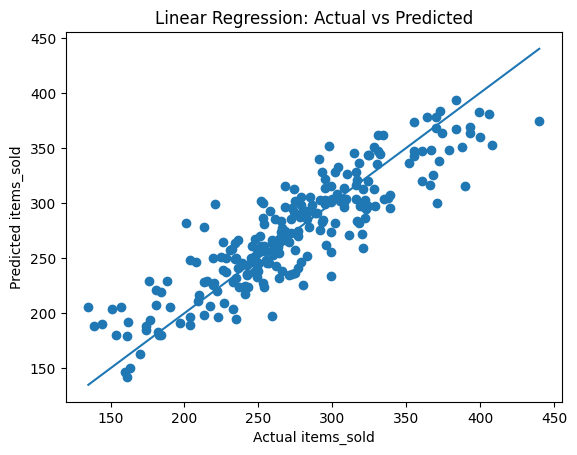

In [17]:
#Step 4: Parity Plot (Linear Regression)
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.title("Linear Regression: Actual vs Predicted")

# Diagonal line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

In [18]:
#Model 2: Random Forest Pipeline
##Build & Train Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

#Step 6: Predictions & Evaluation
y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"Random Forest MAE: {mae_rf:.2f}")

Random Forest RMSE: 30.82
Random Forest MAE: 24.14


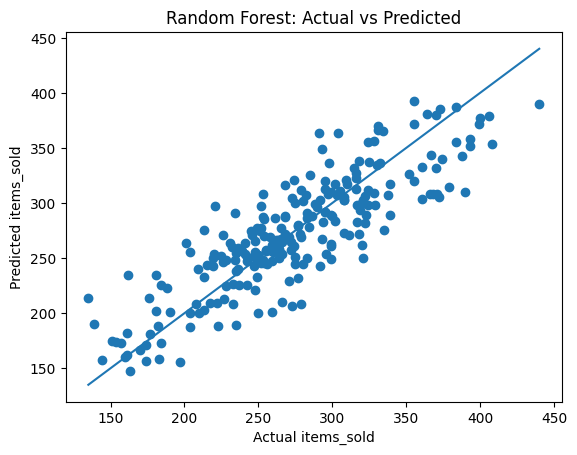

In [19]:
#Parity Plot (Random Forest)
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.title("Random Forest: Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

In [21]:
#Feature Importance (Random Forest)
#Extract Feature Names
# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocessing'].get_feature_names_out()

#Get Feature Importances
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

                     feature  importance
10     cat__store_size_small    0.173360
13          num__is_festival    0.173027
7   cat__location_type_urban    0.111915
17          num__day_of_week    0.086417
12           num__is_weekend    0.063369
11             num__store_id    0.054229
5   cat__location_type_rural    0.050673
8      cat__store_size_large    0.048852
14  num__competition_density    0.048642
16                num__month    0.037841


In [22]:
#Top 5 Features
top5 = feature_importance_df.head(5)
print(top5)

                     feature  importance
10     cat__store_size_small    0.173360
13          num__is_festival    0.173027
7   cat__location_type_urban    0.111915
17          num__day_of_week    0.086417
12           num__is_weekend    0.063369


### Model Comparison

The Random Forest model performs better than Linear Regression as it captures non-linear relationships in the data. Lower RMSE and MAE values indicate improved prediction accuracy.
Feature importance analysis shows that variables such as competition density, promotion type, and seasonal factors significantly influence items sold.
Thus, Random Forest is more suitable for this retail prediction task.